In [1]:
# 이미지가 많은 pdf 문서를 읽어 구현하기 예제
!pip install langchain-community pymupdf pytesseract pillow matplotlib
!pip install transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 5.5 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [2]:
from langchain_community.document_loaders import PyMuPDFLoader
import fitz          # PyMuPDF라는 PDF 처리 라이브러리를 사용 가능. 설치는 pymupdf, import는 fiz
from PIL import Image
import pytesseract     # OCR 사용시 이미지 속의 글자를 텍스트로 추출할 때 사용
import io
import matplotlib.pyplot as plt

# 텍스트 읽기 연습 1) PyMuPDFLoader  사용
pdf_path = "aiethics.pdf"
loader = PyMuPDFLoader(pdf_path)
documents = loader.load()
print(documents)

# 각 Document의 텍스트를 하나의 긴 문자열로 합친다
# 공백이 아닌 텍스트만 추출 (strip())   페이지 간 구분을 위해 \n\n으로 연결
full_text = "\n\n".join([doc.page_content.strip() for doc in documents if doc.page_content.strip()])
print(full_text[:100])

[Document(metadata={'producer': 'Adobe PDF Library 15.0', 'creator': 'Adobe InDesign CC 13.1 (Macintosh)', 'creationdate': '2024-03-07T15:09:14+09:00', 'source': 'aiethics.pdf', 'file_path': 'aiethics.pdf', 'total_pages': 16, 'format': 'PDF 1.3', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2024-03-07T15:09:28+09:00', 'trapped': '', 'modDate': "D:20240307150928+09'00'", 'creationDate': "D:20240307150914+09'00'", 'page': 0}, page_content='전북교육 2023-466\n발\n간\n등\n록\n번\n호\n1'), Document(metadata={'producer': 'Adobe PDF Library 15.0', 'creator': 'Adobe InDesign CC 13.1 (Macintosh)', 'creationdate': '2024-03-07T15:09:14+09:00', 'source': 'aiethics.pdf', 'file_path': 'aiethics.pdf', 'total_pages': 16, 'format': 'PDF 1.3', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2024-03-07T15:09:28+09:00', 'trapped': '', 'modDate': "D:20240307150928+09'00'", 'creationDate': "D:20240307150914+09'00'", 'page': 1}, page_content='똑디(똑똑한 디지털 도우미)와 함께하는 생성형 AI·

In [3]:
# 텍스트 읽기 연습 2) fitz(PyMuPDF)를 사용해서 읽어도 된다. 좀 번거로움
from langchain_core.documents import Document    # LangChain Document 클래스
    # page_content(문서의 내용(텍스트))과 metadata를 담아둘 수 있다.
    # metadata: 문서에 대한 부가 정보를 담는 딕셔너리. 예: 페이지 번호, 원본 파일명, 저자, 제목 등

doc = fitz.open("aiethics.pdf")
documents = []

for i, page in enumerate(doc):
    text = page.get_text()     # 페이지에서 텍스트 추출
    metadata = {
        "source": pdf_path,
        "page": i + 1,
        "total_pages": len(doc),
        "author": doc.metadata.get("author", ""),
        "title": doc.metadata.get("title", ""),
        "producer": doc.metadata.get("producer", "")
    }

    if text.strip():  # 공백만 있는 페이지는 제외. 유의미한 텍스트가 존재하는 경우만 실행
        documents.append(Document(page_content=text.strip(), metadata=metadata))

print(f"총 문서 수: {len(documents)}")
print(documents[0])
full_text = "\n\n".join([doc.page_content.strip() for doc in documents if doc.page_content.strip()])
print(full_text[:100])

총 문서 수: 16
page_content='전북교육 2023-466
발
간
등
록
번
호
1' metadata={'source': 'aiethics.pdf', 'page': 1, 'total_pages': 16, 'author': '', 'title': '', 'producer': 'Adobe PDF Library 15.0'}
전북교육 2023-466
발
간
등
록
번
호
1

똑디(똑똑한 디지털 도우미)와 함께하는 생성형 AI·인공지능 윤리의 모든 것 
전북특별자치도교육청 미래교육과
2

1. 생성형 


[(294, 0, 295, 489, 8, 'DeviceCMYK', '', 'Im0', 'DCTDecode', 0), (296, 0, 989, 495, 8, 'DeviceCMYK', '', 'Im1', 'DCTDecode', 0), (298, 0, 989, 490, 8, 'DeviceCMYK', '', 'Im2', 'DCTDecode', 0), (300, 0, 347, 290, 8, 'DeviceCMYK', '', 'Im3', 'DCTDecode', 0)]
이미지 저장 완료: imgs/page_1_image_1.jpg


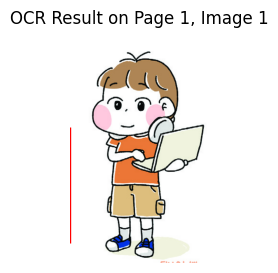

이미지 저장 완료: imgs/page_1_image_2.jpg


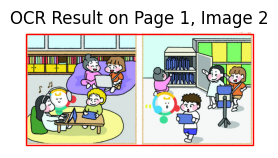

이미지 저장 완료: imgs/page_1_image_3.jpg


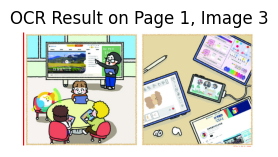

이미지 저장 완료: imgs/page_1_image_4.jpg


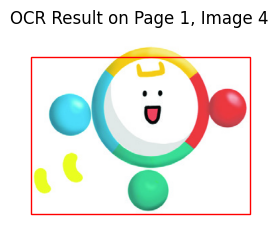

[(4, 0, 1600, 2453, 8, 'DeviceCMYK', '', 'Im0', 'FlateDecode', 0)]
이미지 저장 완료: imgs/page_2_image_1.jpg


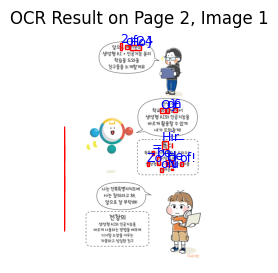

[(8, 0, 234, 197, 8, 'DeviceCMYK', '', 'Im0', 'DCTDecode', 0), (10, 0, 230, 380, 8, 'DeviceCMYK', '', 'Im1', 'DCTDecode', 0)]
이미지 저장 완료: imgs/page_3_image_1.jpg


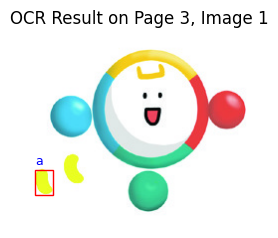

이미지 저장 완료: imgs/page_3_image_2.jpg


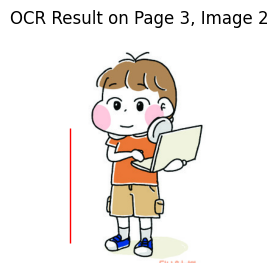

[(26, 0, 231, 103, 8, 'DeviceCMYK', '', 'Im0', 'DCTDecode', 0), (27, 0, 116, 204, 8, 'DeviceCMYK', '', 'Im1', 'FlateDecode', 0), (28, 0, 122, 128, 8, 'DeviceCMYK', '', 'Im10', 'FlateDecode', 0), (29, 0, 122, 128, 8, 'DeviceCMYK', '', 'Im11', 'DCTDecode', 0), (30, 0, 122, 128, 8, 'DeviceCMYK', '', 'Im12', 'FlateDecode', 0), (31, 0, 122, 128, 8, 'DeviceCMYK', '', 'Im13', 'FlateDecode', 0), (32, 0, 122, 128, 8, 'DeviceCMYK', '', 'Im14', 'DCTDecode', 0), (33, 0, 289, 98, 8, 'DeviceCMYK', '', 'Im15', 'DCTDecode', 0), (34, 0, 145, 194, 8, 'DeviceCMYK', '', 'Im16', 'DCTDecode', 0), (35, 0, 289, 98, 8, 'DeviceCMYK', '', 'Im17', 'FlateDecode', 0), (36, 0, 289, 133, 8, 'DeviceCMYK', '', 'Im18', 'DCTDecode', 0), (37, 0, 145, 265, 8, 'DeviceCMYK', '', 'Im19', 'FlateDecode', 0), (38, 0, 231, 103, 8, 'DeviceCMYK', '', 'Im2', 'DCTDecode', 0), (39, 0, 289, 133, 8, 'DeviceCMYK', '', 'Im20', 'DCTDecode', 0), (40, 0, 238, 238, 8, 'DeviceCMYK', '', 'Im21', 'FlateDecode', 0), (41, 0, 231, 103, 8, 'DeviceCM

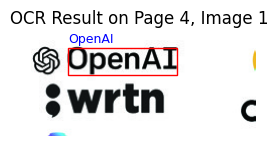

이미지 저장 완료: imgs/page_4_image_2.jpg


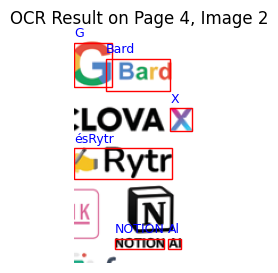

이미지 저장 완료: imgs/page_4_image_3.jpg


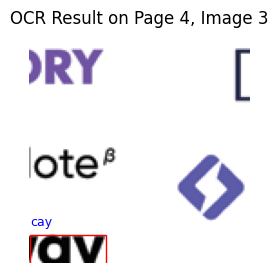

이미지 저장 완료: imgs/page_4_image_4.jpg


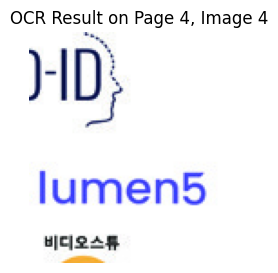

이미지 저장 완료: imgs/page_4_image_5.jpg


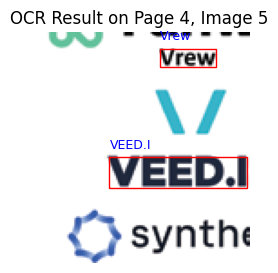

이미지 저장 완료: imgs/page_4_image_6.jpg


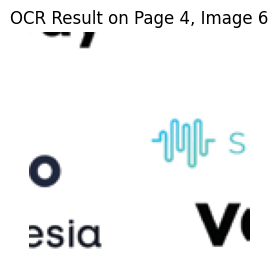

이미지 저장 완료: imgs/page_4_image_7.jpg


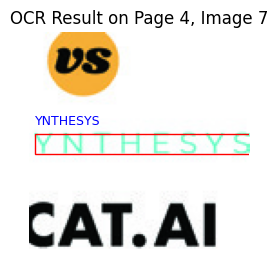

이미지 저장 완료: imgs/page_4_image_8.jpg


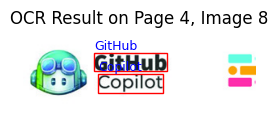

이미지 저장 완료: imgs/page_4_image_9.jpg


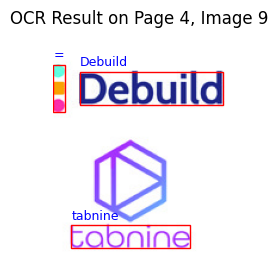

이미지 저장 완료: imgs/page_4_image_10.jpg


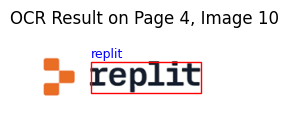

이미지 저장 완료: imgs/page_4_image_11.jpg


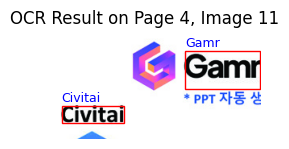

이미지 저장 완료: imgs/page_4_image_12.jpg


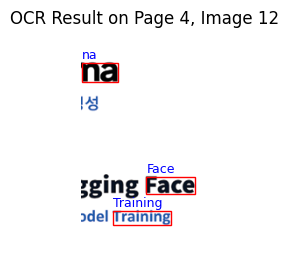

이미지 저장 완료: imgs/page_4_image_13.jpg


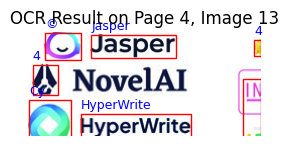

이미지 저장 완료: imgs/page_4_image_14.jpg


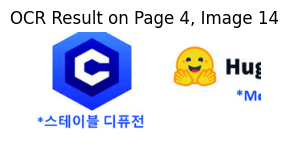

이미지 저장 완료: imgs/page_4_image_15.jpg


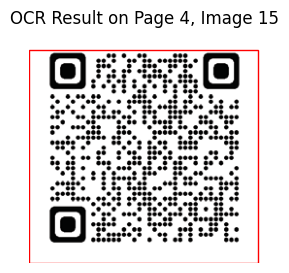

이미지 저장 완료: imgs/page_4_image_16.jpg


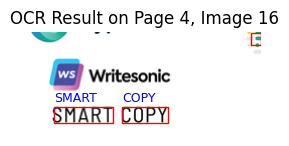

이미지 저장 완료: imgs/page_4_image_17.jpg


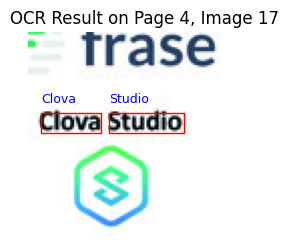

이미지 저장 완료: imgs/page_4_image_18.jpg


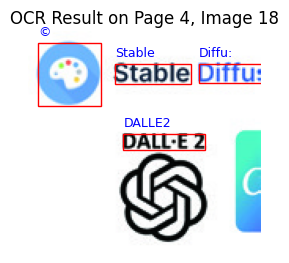

이미지 저장 완료: imgs/page_4_image_19.jpg


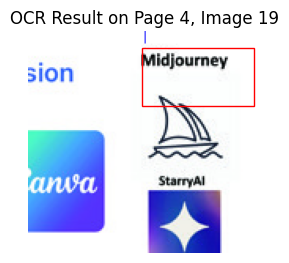

이미지 저장 완료: imgs/page_4_image_20.jpg


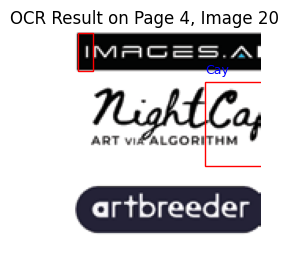

이미지 저장 완료: imgs/page_4_image_21.jpg


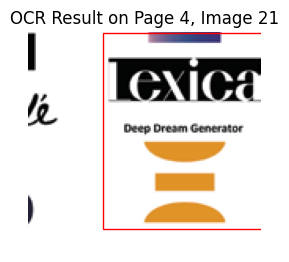

이미지 저장 완료: imgs/page_4_image_22.jpg


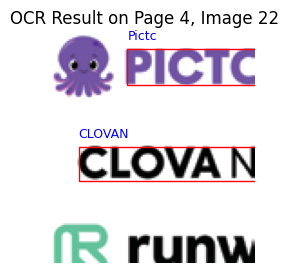

[(51, 0, 1600, 1600, 8, 'DeviceCMYK', '', 'Im0', 'DCTDecode', 0), (217, 0, 214, 180, 8, 'DeviceCMYK', '', 'Im1', 'DCTDecode', 0)]
이미지 저장 완료: imgs/page_5_image_1.jpg


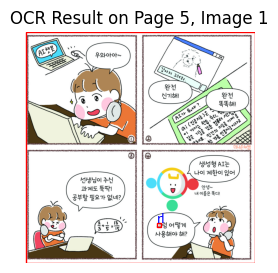

이미지 저장 완료: imgs/page_5_image_2.jpg


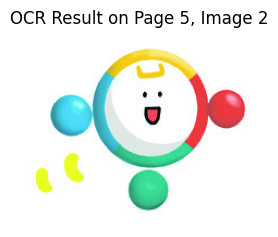

[(55, 0, 1600, 1600, 8, 'DeviceCMYK', '', 'Im0', 'DCTDecode', 0), (217, 0, 214, 180, 8, 'DeviceCMYK', '', 'Im1', 'DCTDecode', 0)]
이미지 저장 완료: imgs/page_6_image_1.jpg


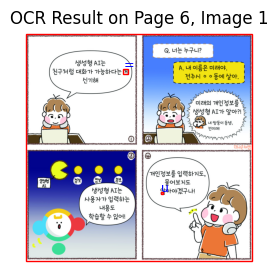

이미지 저장 완료: imgs/page_6_image_2.jpg


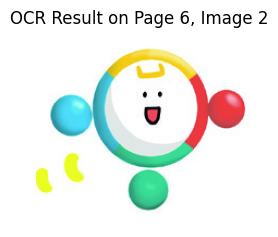

[(58, 0, 1280, 1280, 8, 'DeviceCMYK', '', 'Im0', 'DCTDecode', 0), (217, 0, 214, 180, 8, 'DeviceCMYK', '', 'Im1', 'DCTDecode', 0)]
이미지 저장 완료: imgs/page_7_image_1.jpg


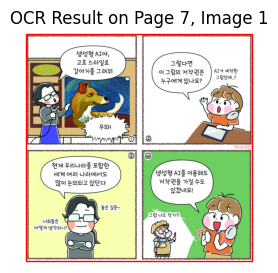

이미지 저장 완료: imgs/page_7_image_2.jpg


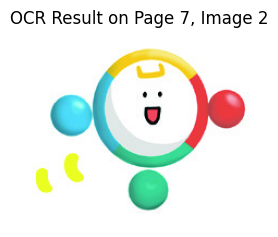

[(61, 0, 1280, 1280, 8, 'DeviceCMYK', '', 'Im0', 'DCTDecode', 0), (217, 0, 214, 180, 8, 'DeviceCMYK', '', 'Im1', 'DCTDecode', 0), (62, 0, 312, 321, 8, 'DeviceCMYK', '', 'Im2', 'DCTDecode', 0)]
이미지 저장 완료: imgs/page_8_image_1.jpg


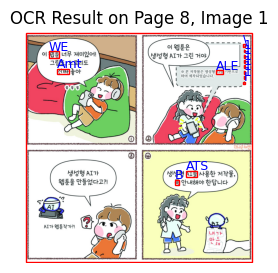

이미지 저장 완료: imgs/page_8_image_2.jpg


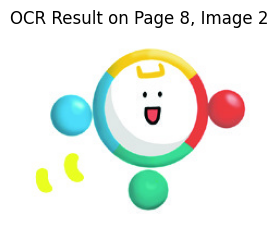

이미지 저장 완료: imgs/page_8_image_3.jpg


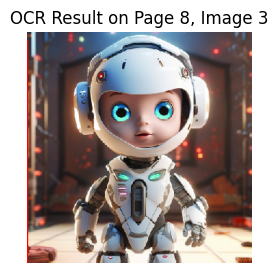

[(80, 0, 1600, 1600, 8, 'DeviceCMYK', '', 'Im0', 'FlateDecode', 0), (217, 0, 214, 180, 8, 'DeviceCMYK', '', 'Im1', 'DCTDecode', 0)]
이미지 저장 완료: imgs/page_9_image_1.jpg


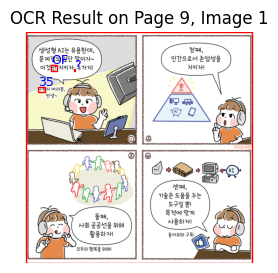

이미지 저장 완료: imgs/page_9_image_2.jpg


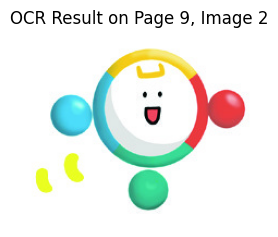

[(84, 0, 1600, 1600, 8, 'DeviceCMYK', '', 'Im0', 'DCTDecode', 0)]
이미지 저장 완료: imgs/page_10_image_1.jpg


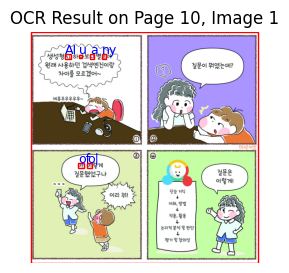

[(111, 0, 1280, 1280, 8, 'DeviceCMYK', '', 'Im0', 'DCTDecode', 0), (217, 0, 214, 180, 8, 'DeviceCMYK', '', 'Im1', 'DCTDecode', 0)]
이미지 저장 완료: imgs/page_13_image_1.jpg


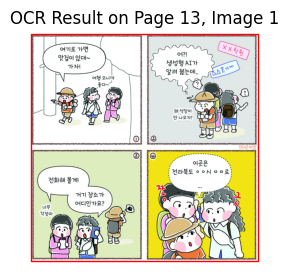

이미지 저장 완료: imgs/page_13_image_2.jpg


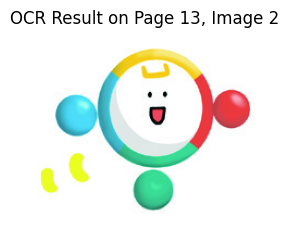

[(115, 0, 1600, 1600, 8, 'DeviceCMYK', '', 'Im0', 'DCTDecode', 0), (217, 0, 214, 180, 8, 'DeviceCMYK', '', 'Im1', 'DCTDecode', 0)]
이미지 저장 완료: imgs/page_14_image_1.jpg


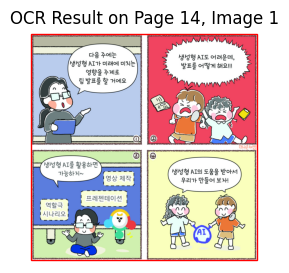

이미지 저장 완료: imgs/page_14_image_2.jpg


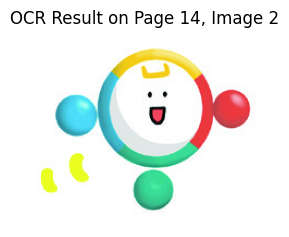

[(133, 0, 448, 745, 8, 'DeviceCMYK', '', 'Im0', 'FlateDecode', 0)]
이미지 저장 완료: imgs/page_15_image_1.jpg


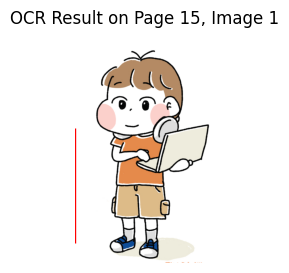

[(137, 0, 207, 174, 8, 'DeviceCMYK', '', 'Im0', 'DCTDecode', 0), (139, 0, 186, 307, 8, 'DeviceCMYK', '', 'Im1', 'FlateDecode', 0)]
이미지 저장 완료: imgs/page_16_image_1.jpg


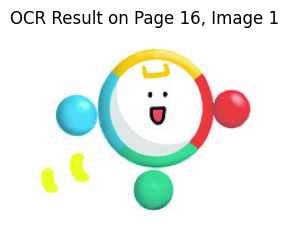

이미지 저장 완료: imgs/page_16_image_2.jpg


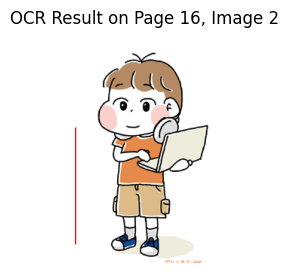

[{'page': 1, 'image_index': 1, 'text': ''}, {'page': 1, 'image_index': 2, 'text': ''}]


In [4]:
# 이제는 PDF 문서의 이미지 읽기 연습
# OCR (Optical Character Recognition, 광학 문자 인식)을 적용하는 것은 다음과 같은 흐름으로 진행됨.
#  - PDF에 포함된 텍스트 이미지 (스캔된 문서, 사진) 등에서 글자를 인식해서 텍스트로 추출하는 작업.
#  - 예: 이미지에 "abc"라는 글자가 찍혀 있다면 → OCR을 통해 "abc"라는 문자열을 얻을 수 있다.

# fitz.open()은 PyMuPDF 원래방식(PDF 내부구조 그대로)으로 로드 한다.
# 문서 내 이미지 중심 작업을 위해 필요하다. 즉, 텍스트가 아니 OCR을 하기 위함.
doc = fitz.open(pdf_path)
ocr_results = []   # OCR 결과를 저장할 리스트

import os
for page_num, page in enumerate(doc):
    # 각 페이지에서 이미지 목록을 가져온다. (full=True: 모든 이미지 대상)
    images = page.get_images(full=True)
    if not images:
        continue      # 이미지가 없다면 해당 페이지 건너 뜀

    print(images)

    for i, img in enumerate(images):
        xref = img[0]     # xref: 이미지의 참조 ID
        base_image = doc.extract_image(xref)  # 이미지 데이터를 추출
        image_bytes = base_image["image"]    # image_bytes: 이미지의 raw 바이트 데이터를 가져옴
        image = Image.open(io.BytesIO(image_bytes))     # 바이트 데이터를 PIL.Image 객체로 열기

        # 문서에서 읽은 이미지를 각각 파일로 저장
        save_dir = "imgs"
        os.makedirs(save_dir, exist_ok=True)

        # 이미지 저장
        image_filename = f"page_{page_num + 1}_image_{i + 1}.jpg"
        image_path = os.path.join(save_dir, image_filename)
        image.save(image_path)
        print(f"이미지 저장 완료: {image_path}")

        # OCR 수행 결과를 딕셔너리 형태로 반환 (텍스트, 위치 정보, 신뢰도 등 포함)
        # image_to_data는 이미지 분석 후, 텍스트+위치+confidence 등의 정보를 dict 형식으로 반환
        data = pytesseract.image_to_data(image, output_type=pytesseract.Output.DICT)

        # data["text"]	OCR로 인식된 단어들의 리스트
        # 신뢰도(conf)가 60 이상인 단어만 골라(잡음제거 목적) 문자열로 결합(OCR의 잡음제거 필터 역할)
        extracted_text = " ".join([text for j, text in enumerate(data["text"]) if int(data["conf"][j]) > 60])
        ocr_results.append({
            "page": page_num + 1,
            "image_index": i + 1,
            "text": extracted_text
        })   # OCR 결과를 페이지번호, 이미지 번호와 함께 저장

        plt.figure(figsize=(3, 3))
        plt.imshow(image)
        for j in range(len(data["text"])):  # j는 단어 인덱스(예: 0번째 단어, 1번째 단어 ...)
            if int(data["conf"][j]) > 60:    # OCR 텍스트 중 신뢰도 60 이상인 것만 시각적으로 표시
                 # 각 텍스트 위치에 빨간 사각형, 텍스트는 파란색으로 표시
                 # 위치 좌표 추출
                (x, y, w, h) = (data["left"][ j ], data["top"][ j ], data["width"][ j ], data["height"][ j ] )
                plt.gca().add_patch(plt.Rectangle((x, y), w, h, edgecolor='red', facecolor='none', linewidth=1))

                # 사각형 위에 인식된 단어 자체를 파란색 텍스트로 출력
                # y - 5는 텍스트가 사각형 위에 살짝 떠 있도록 조절
                plt.text(x, y - 5, data["text"][j], color='blue', fontsize=9)
        plt.axis('off')
        plt.title(f"OCR Result on Page {page_num+1}, Image {i+1}")
        plt.show()

# 일부 결과 출력
print(ocr_results[:2])

In [7]:
!apt-get update
!apt-get install -y tesseract-ocr tesseract-ocr-kor

import pytesseract
pytesseract.pytesseract.tesseract_cmd = r'/usr/bin/tesseract'

print(pytesseract.get_languages(config=""))


Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:2 https://cli.github.com/packages stable InRelease
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.6 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,081 kB]
Get:10 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,201 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:13 http://archive.ubuntu.com/ubun

In [8]:
# 저장된 이미지들 중 실제 텍스트가 있는 이미지만 OCR 출력. 2글자 이상만 출력 + 확대 OCR 로 정확도 향상
import os
from PIL import Image
import pytesseract
import re
import numpy as np
import cv2

KOR_RE = re.compile(r"[가-힣a-zA-Z]{2,}")  # 한국어,영어만 추출: 최소 2글자 이상

# imgs 폴더 안의 이미지들을 대상으로 OCR 수행하여, 2글자 이상만 출력.
def show_korean_imgFunc(img_dir: str = "imgs", lang: str = "kor+eng"):
    # 폴더 유효성 검사
    if not os.path.isdir(img_dir):
        print(f"[경고] 폴더가 없습니다: {img_dir}")
        return

    valid_exts = (".jpg", ".jpeg", ".png")  # 허용되는 이미지 확장자

    # 폴더 안의 이미지 파일 목록 로드
    image_files = [
        f for f in sorted(os.listdir(img_dir))
        if f.lower().endswith(valid_exts)
    ]

    if not image_files:
        print(f"[안내] {img_dir} 폴더 안에 이미지 X")
        return

    print("\n2글자 이상만 출력 (확대 OCR 적용)\n")
    found_any_text = False  # 글이 추출된 이미지가 하나라도 있었는지 감지용

    for fname in image_files:
        img_path = os.path.join(img_dir, fname)
        img = Image.open(img_path)  # PIL 이미지 로드
        np_img = np.array(img)        # PIL → NumPy 배열로 변환

        # OCR 정확도 향상을 위한 이미지 확대.  interpolation=INTER_LINEAR: 자연스러운 확대
        scaled_img = cv2.resize(np_img, None, fx=2, fy=2, interpolation=cv2.INTER_LINEAR)
        raw_text = pytesseract.image_to_string(scaled_img, lang=lang)
        korean_words = KOR_RE.findall(raw_text)  # 2글자 이상만 정규식으로 추출

        # 한글 단어가 하나도 없으면 skip
        if not korean_words:
            continue

        found_any_text = True
        print("-" * 50)
        print(f"이미지 파일:{fname}")
        print(" ".join(korean_words))  # 2글자 이상 단어들만 출력

    # 한글 단어가 하나도 없었던 경우
    if not found_any_text:
        print("[결과] 2글자 이상 단어가 포함된 이미지 X")

show_korean_imgFunc("imgs", "kor+eng")


2글자 이상만 출력 (확대 OCR 적용)

--------------------------------------------------
이미지 파일:page_10_image_1.jpg
oll Oe Ms 니사 이리
--------------------------------------------------
이미지 파일:page_13_image_1.jpg
en Seay RN aE oz Ji ae rare zy eR os on 버르 PEE ASE ES Me re 소가 인카요 Ps Eu bly Of Ss sz
--------------------------------------------------
이미지 파일:page_14_image_1.jpg
다음 수에는 ii AIS 어떻게 해요 주제로 트럭 거에요
--------------------------------------------------
이미지 파일:page_2_image_1.jpg
ee ety oF og LO to of SS Ss SST Ss Ss SS 대데띄 태세디 태제디 태기 개애에 너나 aM 때베 때채 재재 대내 baby
--------------------------------------------------
이미지 파일:page_4_image_1.jpg
OpenAI swrtn
--------------------------------------------------
이미지 파일:page_4_image_10.jpg
replit
--------------------------------------------------
이미지 파일:page_4_image_11.jpg
Civitai Gamr
--------------------------------------------------
이미지 파일:page_4_image_12.jpg
na odel Training
--------------------------------------------------
이미지 파일:page_4_image_13.jpg
NovelAl 